# <center> Car Price Prediction</center>

# Introduction

The Car Price Prediction Project is a machine learning-based application designed to estimate the selling price of used cars based on their features and specifications. Buying and selling used cars often requires accurate price estimation, which can be difficult due to factors such as vehicle age, kilometers driven, fuel type, transmission, engine power, brand, and model.

This project uses historical car data to train a machine learning model that learns patterns between car features and their market prices. After training, the model can predict the approximate selling price of a car when new input details are provided.

The main objective of this project is to apply data preprocessing, exploratory data analysis, feature engineering, model training, and evaluation techniques to build an accurate and reliable prediction system. This project demonstrates how machine learning can be used in real-world business applications such as automobile resale price estimation.

## Importing Required Libraries

In this step, we import all the necessary Python libraries required for data analysis, visualization, and model building.

- pandas and numpy → Used for data manipulation and numerical operations  
- matplotlib and seaborn → Used for data visualization and plotting graphs  
- plotly.express → Used for interactive visualizations  
- warnings → Used to ignore unnecessary warning messages  
- urllib (from six.moves) → Helps in handling URL-related operations  

We also enable inline plotting using `%matplotlib inline` so that graphs are displayed directly inside the Jupyter Notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from six.moves import urllib

warnings.filterwarnings("ignore")

%matplotlib inline

## Loading the Dataset

In this step, we load the dataset into a pandas DataFrame using the `read_csv()` function. The dataset used here is the CarDekho dataset, which contains information about used cars such as brand, model, age, fuel type, transmission, kilometers driven, and selling price.

After loading the data, we use `head()` to display the first 5 rows of the dataset. This helps us understand the structure of the data and verify that it has been loaded correctly.

In [3]:
car = pd.read_csv('cardekho_dataset.csv')

car.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## Dataset Information

The `info()` function is used to get a concise summary of the dataset. It provides important details such as:

- Total number of rows and columns  
- Column names and their data types  
- Number of non-null values in each column  
- Memory usage of the dataset  

This step helps us understand the structure of the dataset and identify if there are any missing values or incorrect data types that need to be handled during preprocessing.

In [4]:
car.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


## Statistical Summary of the Dataset

The `describe()` function provides a statistical summary of all numerical columns in the dataset. It helps us understand the distribution and central tendency of the data.

It includes the following metrics:

- count → Number of non-null values  
- mean → Average value  
- std → Standard deviation (spread of data)  
- min → Minimum value  
- 25%, 50%, 75% → Quartile values  
- max → Maximum value  

This step is useful for detecting outliers, understanding data distribution, and gaining insights before building the model.

In [5]:
car.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


## Summary of Categorical Features

The `describe(include='object')` function provides a statistical summary of all categorical (text) columns in the dataset.

It includes the following information:

- count → Number of non-null values in each column  
- unique → Number of unique categories in each column  
- top → Most frequently occurring category  
- freq → Frequency of the most common category  

This step helps us understand the distribution of categorical variables such as brand, fuel type, transmission type, and seller type. It is useful for identifying dominant categories and preparing the data for encoding.

In [6]:
car.describe(include='object')

,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


## Shape of the Dataset

The `shape` attribute is used to find the dimensions of the dataset.

It returns:

- Number of rows (records)  
- Number of columns (features)  

This helps us understand how large the dataset is and gives an idea about the amount of data available for training the machine learning model.

In [9]:
car.shape

(15411, 14)

## Identifying Numerical and Categorical Columns

In this step, we separate the dataset features into numerical and categorical columns based on their data types.

- Numerical columns include integer and float data types (int64, float64). These columns contain continuous or measurable values such as vehicle age, kilometers driven, mileage, engine power, and price.

- Categorical columns include object (string) data types. These represent categories such as brand, model, fuel type, transmission type, and seller type.

This separation is important for preprocessing, as numerical and categorical features are handled differently during model building.

In [10]:
num_cols = car.select_dtypes(include=['int64', 'float64']).columns
cat_cols = car.select_dtypes(include='object').columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Categorical: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [11]:
car

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


## Checking Missing Values

The `isnull().sum()` function is used to check the number of missing (null) values in each column of the dataset.

This step helps us identify if any data cleaning or imputation is required before building the machine learning model. Handling missing values is important to ensure the accuracy and reliability of the model.m

In [12]:
car.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

## Statistical Summary of Numerical Data

The `describe()` function is used to generate a statistical summary of all numerical columns in the dataset.

It provides key information such as:
- count → number of non-null values  
- mean → average value  
- std → standard deviation (spread of data)  
- min → minimum value  
- 25%, 50%, 75% → quartile values  
- max → maximum value  

This helps in understanding the distribution of numerical features and identifying patterns or potential outliers in the data before model building.

In [92]:
car.describe

<bound method NDFrame.describe of        Unnamed: 0         car_name     brand     model  vehicle_age  \
0               0      Maruti Alto    Maruti      Alto            9   
1               1    Hyundai Grand   Hyundai     Grand            5   
2               2      Hyundai i20   Hyundai       i20           11   
3               3      Maruti Alto    Maruti      Alto            9   
4               4    Ford Ecosport      Ford  Ecosport            6   
...           ...              ...       ...       ...          ...   
15406       19537      Hyundai i10   Hyundai       i10            9   
15407       19540    Maruti Ertiga    Maruti    Ertiga            2   
15408       19541      Skoda Rapid     Skoda     Rapid            6   
15409       19542  Mahindra XUV500  Mahindra    XUV500            5   
15410       19543       Honda City     Honda      City            2   

       km_driven seller_type fuel_type transmission_type  mileage  engine  \
0         120000  Individual    Petr

## Statistical Summary of Categorical Data

The `describe(include='object')` function provides a summary of all categorical (non-numerical) columns in the dataset.

It shows important details such as:
- count → number of non-null values  
- unique → number of unique categories in each column  
- top → most frequently occurring category  
- freq → frequency of the most common category  

This helps us understand the distribution of categorical features like brand, model, fuel type, transmission type, and seller type. It is useful for identifying dominant categories and preparing data for encoding in machine learning.

In [93]:
car.describe(include='object')

,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


## Analysis of Missing Values

In this step, we analyze the presence of missing values in each column of the dataset.

We calculate:
- Total number of missing values in each column  
- Percentage of missing values relative to the dataset size  

This helps us clearly understand which features contain missing data and how significant the issue is. Based on this analysis, we can decide whether to remove, fill, or handle missing values using appropriate data preprocessing techniques.

Displaying both total count and percentage gives a better insight into the quality of the dataset.

In [94]:
print('Missing value presence in different columns of data farmes are as follows')
print('_'*100)

total = car.isnull().sum().sort_values(ascending=False)

percent = (car.isnull().sum()/ car.isnull().count()*100).sort_values(ascending=False)
pd.concat([total,percent], axis=1, keys=['total','percent'])

Missing value presence in different columns of data farmes are as follows
____________________________________________________________________________________________________


,total,percent
Unnamed: 0,0,0.0
car_name,0,0.0
brand,0,0.0
model,0,0.0
vehicle_age,0,0.0
km_driven,0,0.0
seller_type,0,0.0
fuel_type,0,0.0
transmission_type,0,0.0
mileage,0,0.0


## Checking Unique Values and Data Consistency

In this step, we check the unique categories present in different categorical columns to identify any spelling mistakes, inconsistencies, or unusual values.

We analyze columns such as:
- car_name  
- brand  
- model  
- seller_type  
- fuel_type  
- transmission_type  

For each column, we display:
- Number of unique categories  
- List of unique values  

This helps us detect data issues like typo errors, inconsistent naming, or unexpected categories. It is an important step in data cleaning before encoding categorical variables for machine learning models.

In [105]:
print('_' *125)
print('checking records for mispill , typo error')
print('_' *125)

print("'car_name' variable have {} unique category: \n{}\n".format(car['car_name'].nunique(),car['car_name'].unique))
print('_' *125)

print("'brand' variable have {} unique category: \n{}\n".format(car['brand'].nunique(),car['brand'].unique))
print('_' *125)

print("'model' variable have {} unique category: \n{}\n".format(car['model'].nunique(),car['model'].unique))
print('_' *125)

print("'seller_type' variable have {} unique category: \n{}\n".format(car['seller_type'].nunique(),car['seller_type'].unique))
print('_' *125)
print("'fuel_type' variable have {} unique category: \n{}\n".format(car['fuel_type'].nunique(),car['fuel_type'].unique))
print('_' *125)
print("'transmisson_type' variable have {} unique category: \n{}\n".format(car['transmission_type'].nunique(),car['transmission_type'].unique))


_____________________________________________________________________________________________________________________________
checking records for mispill , typo error
_____________________________________________________________________________________________________________________________
'car_name' variable have 121 unique category: 
<bound method Series.unique of 0            Maruti Alto
1          Hyundai Grand
2            Hyundai i20
3            Maruti Alto
4          Ford Ecosport
              ...       
15406        Hyundai i10
15407      Maruti Ertiga
15408        Skoda Rapid
15409    Mahindra XUV500
15410         Honda City
Name: car_name, Length: 15411, dtype: str>

_____________________________________________________________________________________________________________________________
'brand' variable have 32 unique category: 
<bound method Series.unique of 0          Maruti
1         Hyundai
2         Hyundai
3          Maruti
4            Ford
           ...   
1

## Percentage Distribution of Categorical Columns

In this step, we calculate the percentage distribution of each category present in the categorical columns of the dataset.

Using `value_counts(normalize=True) * 100`, we convert the frequency of each category into percentages.

This helps us understand:
- Which categories are most dominant in each feature  
- How balanced or imbalanced the categorical data is  
- The distribution pattern of features like brand, fuel type, transmission type, and seller type  

This analysis is useful for feature understanding and helps in better preprocessing decisions such as encoding or handling rare categories.

In [96]:
print('_' *100)
print('the percentage of each category in categorical column')
print('_'*100 +'\n')
for col in cat_cols:
    print(car[col].value_counts(normalize=True) * 100)
    print('_'*100)

____________________________________________________________________________________________________
the percentage of each category in categorical column
____________________________________________________________________________________________________

car_name
Hyundai i20              5.878918
Maruti Swift Dzire       5.775096
Maruti Swift             5.067809
Maruti Alto              5.048342
Honda City               4.912076
                           ...   
Mercedes-AMG C           0.006489
Rolls-Royce Ghost        0.006489
Maserati Quattroporte    0.006489
Isuzu MUX                0.006489
Force Gurkha             0.006489
Name: proportion, Length: 121, dtype: float64
____________________________________________________________________________________________________
brand
Maruti           32.392447
Hyundai          19.349815
Honda             9.635974
Mahindra          6.560249
Toyota            5.145675
Ford              5.126209
Volkswagen        4.023100
Renault           

## Univariate Analysis of Numerical Features

In this step, we perform univariate analysis on all numerical features using Kernel Density Estimation (KDE) plots.

We use seaborn's `kdeplot` to visualize the distribution of each numerical column individually. This helps us understand:

- The distribution pattern of each feature  
- Whether the data is normally distributed or skewed  
- Presence of peaks or outliers in the data  

We also use subplots to display multiple graphs in a single figure for better comparison and visualization of all numerical features.

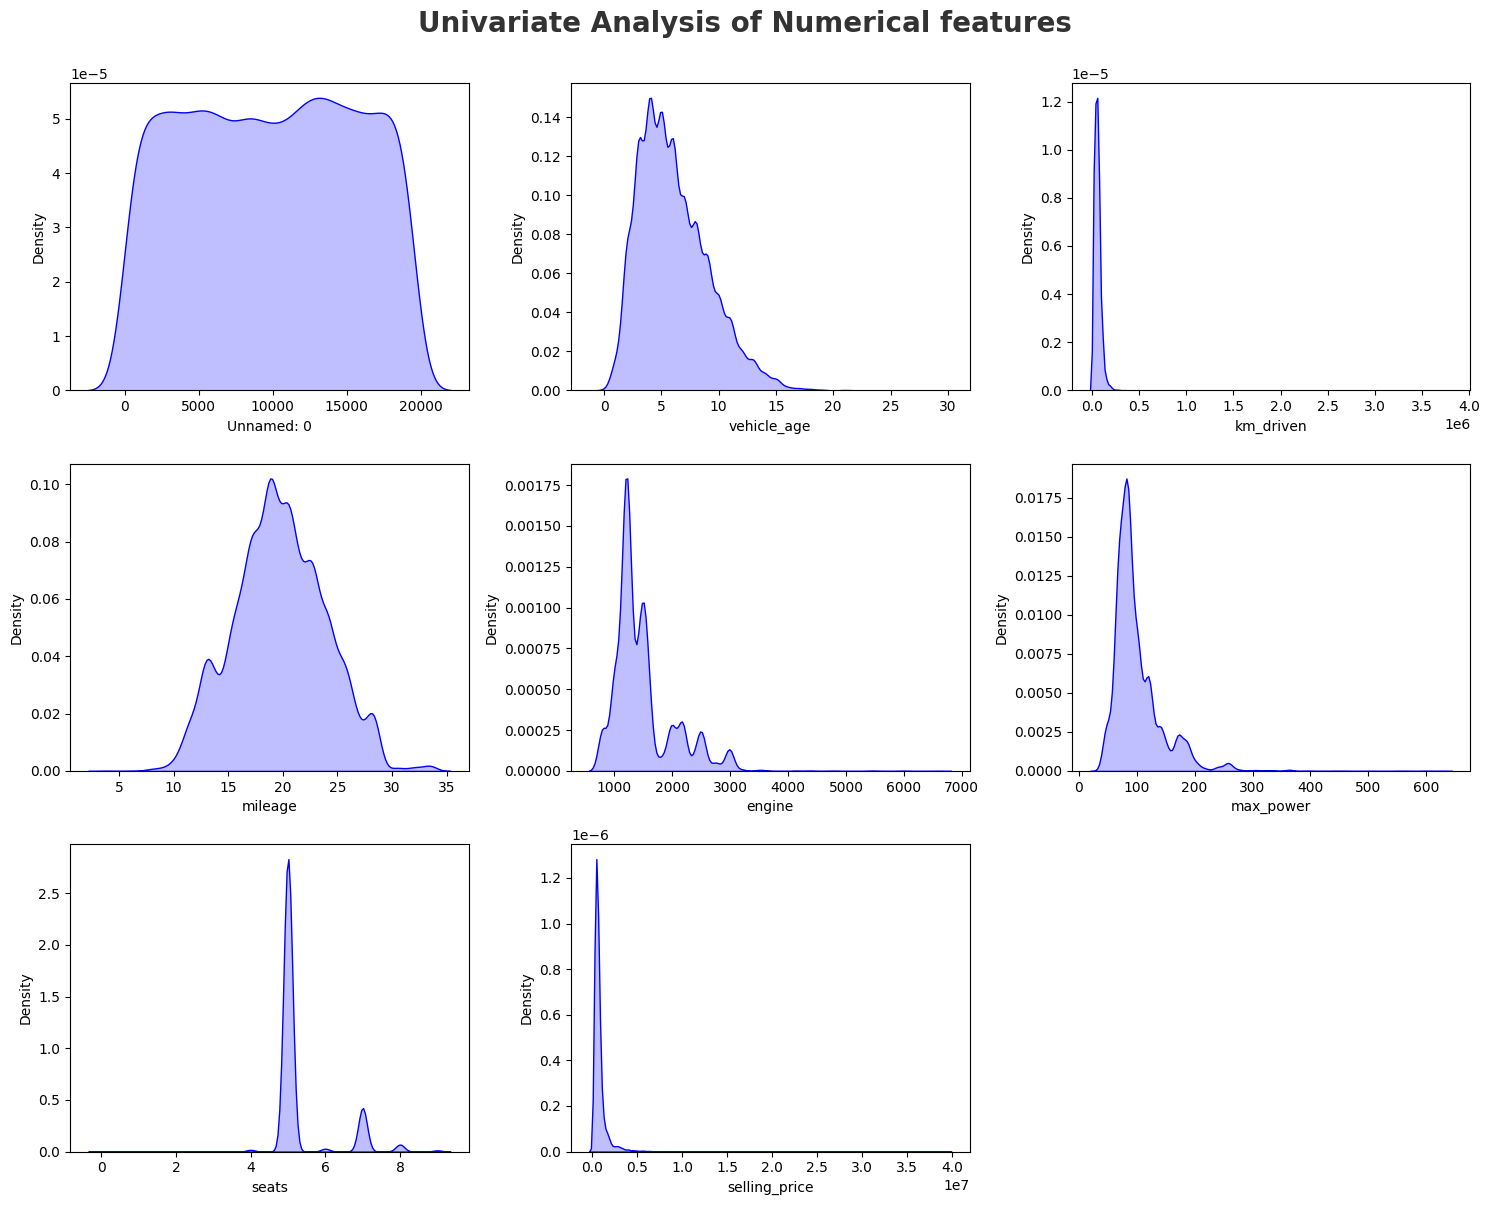

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming num_cols is a list of column names
plt.figure(figsize=(15, 12)) # Recommended to define figure size
plt.suptitle("Univariate Analysis of Numerical features",fontsize=20, fontweight='bold',alpha=0.8, y=1.0)
for i in range(0, len(num_cols)):
    plt.subplot(3, 3, i + 1)
    # Select the specific column using the index i
    sns.kdeplot(data=car, x=num_cols[i], fill=True, color='b')
    plt.xlabel(num_cols[i])
    plt.tight_layout()

plt.show()

## Univariate Analysis using Boxplots

In this step, we use boxplots to analyze the distribution of numerical features in the dataset.

Boxplots help us understand:
- The median (central value) of the data  
- The spread of the data (interquartile range)  
- Presence of outliers in each feature  

By plotting boxplots for all numerical columns, we can easily detect extreme values and understand how data is distributed across different features such as vehicle age, kilometers driven, mileage, engine power, and price.

This step is very useful for identifying outliers before building the machine learning model.

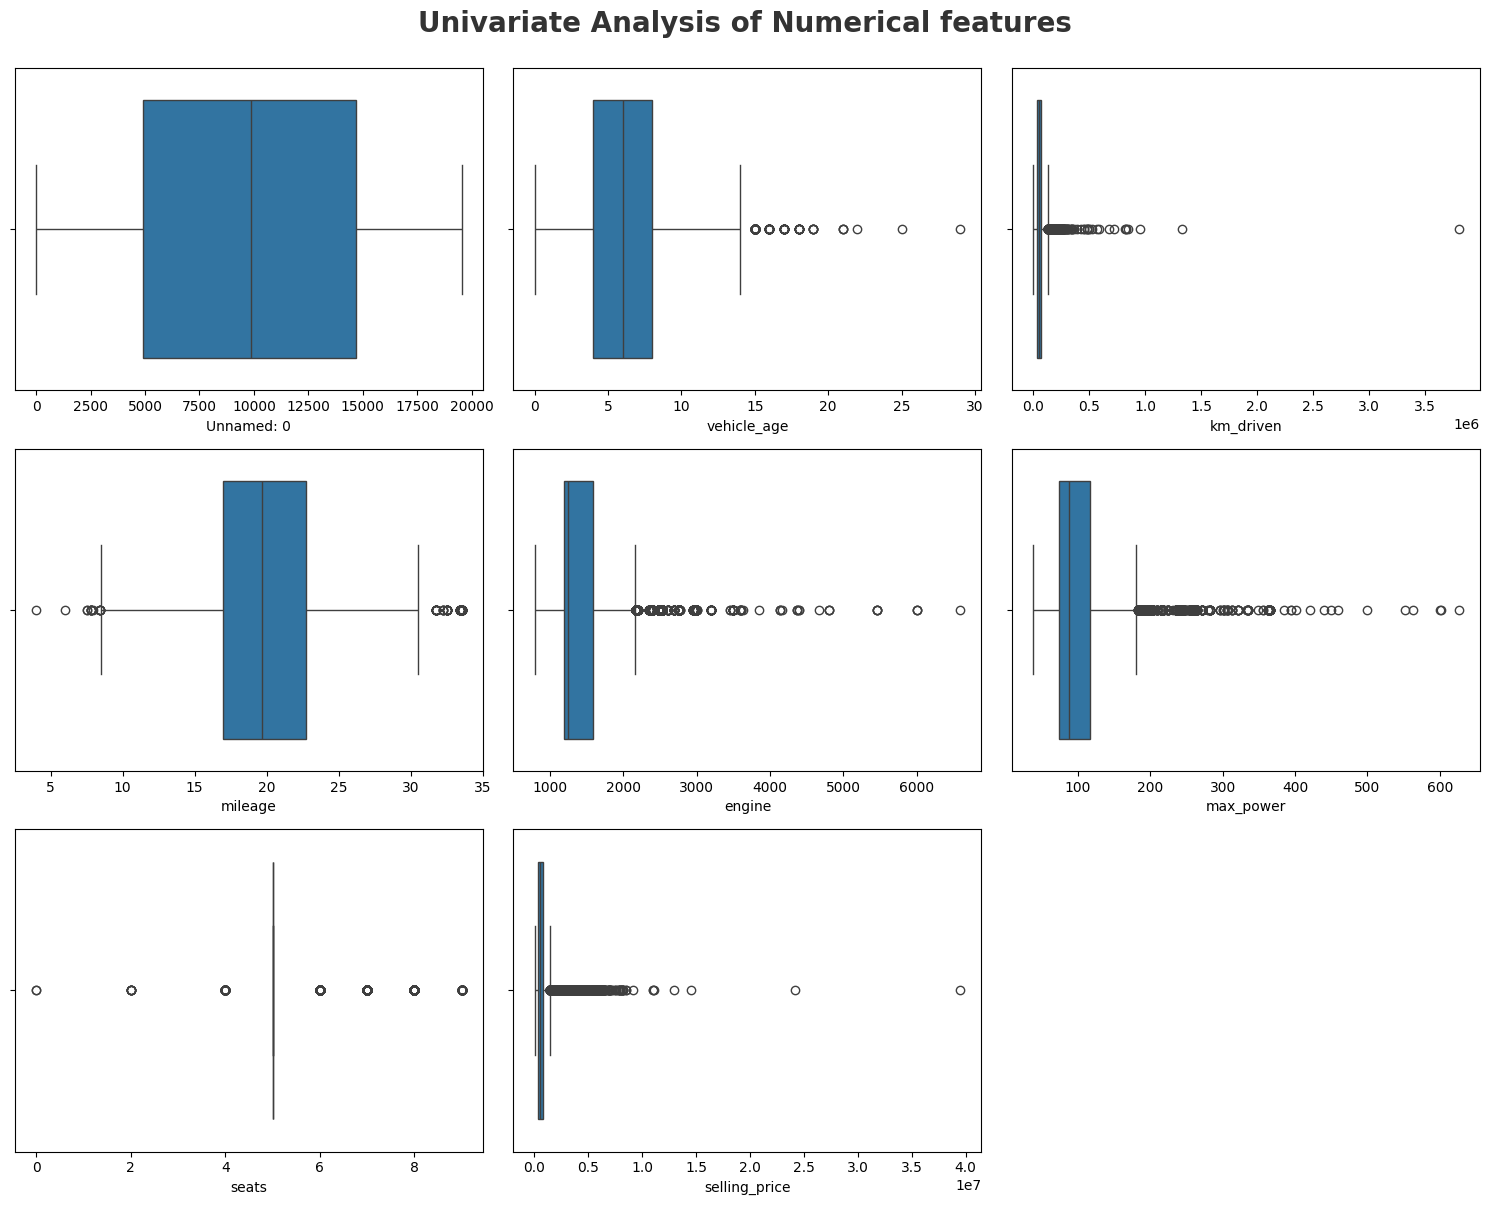

In [98]:
plt.figure(figsize=(15, 12)) # Recommended to define figure size
plt.suptitle("Univariate Analysis of Numerical features",fontsize=20, fontweight='bold',alpha=0.8, y=1.0)
for i in range(0, len(num_cols)):
    plt.subplot(3, 3, i + 1)
    # Select the specific column using the index i
    sns.boxplot(x=car[num_cols[i]])
    plt.xlabel(num_cols[i])
    plt.tight_layout()

plt.show()

## Univariate Analysis of Categorical Features

In this step, we perform univariate analysis on categorical features using count plots.

We use seaborn’s `countplot` to visualize the frequency of each category in the selected columns such as:
- car_name  
- brand  
- model  
- seller_type  
- fuel_type  
- transmission_type  

This helps us understand:
- The distribution of different categories in each feature  
- Which categories are most frequently occurring  
- Whether any category is dominating the dataset  

We also rotate the x-axis labels for better readability, since some category names are long and may overlap in the plots.

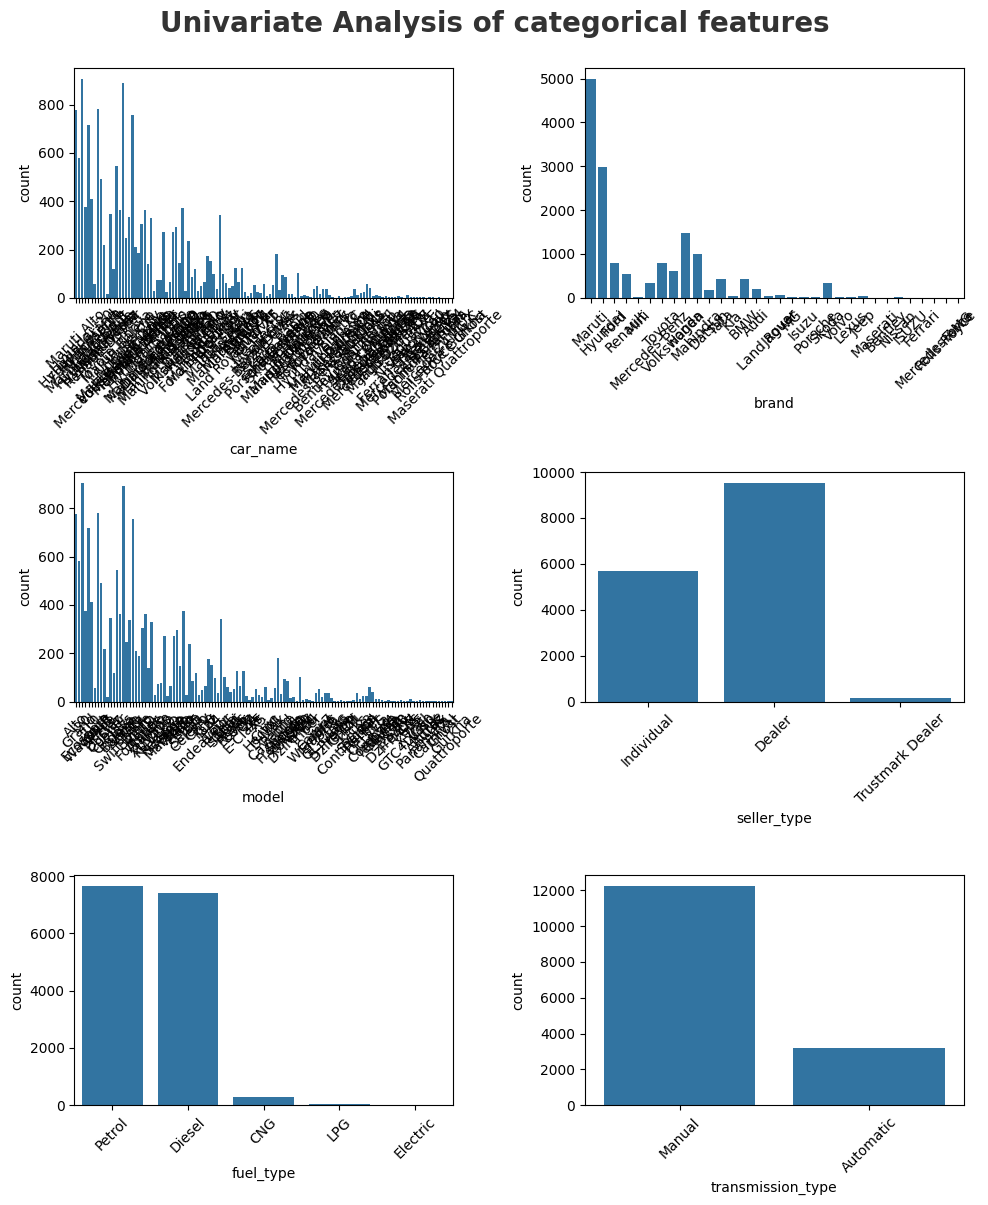

In [99]:
cat = ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

plt.figure(figsize=(10, 12)) # Make the window bigger so plots aren't squashed
plt.suptitle("Univariate Analysis of categorical features",fontsize=20, fontweight='bold',alpha=0.8, y=1.0)

for i in range(len(cat)):
    plt.subplot(3, 2, i + 1)  # 3 rows, 2 columns = 6 slots
    sns.countplot(data=car, x=cat[i])
    plt.xticks(rotation=45)    # Rotates names so they don't overlap

plt.tight_layout()

# Bivariant analysis

## Identifying Continuous Features

In this step, we identify continuous numerical features from the dataset.

A feature is considered continuous if it has a large number of unique values (here, we use a threshold of 10 or more unique values).

We filter these features from all numerical columns to focus only on variables that represent continuous data rather than discrete or categorical-like numeric values.

This step helps us:
- Separate meaningful continuous variables for analysis  
- Improve visualization and modeling efficiency  
- Focus on features that have real numerical variation such as mileage, engine capacity, and kilometers driven  

In [100]:
continuous_features = [feature for feature in num_cols if len(car[feature].unique())>=10]
print("Num of continuous features:", continuous_features)

Num of continuous features: ['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'selling_price']


## Relationship Between Selling Price and Numerical Features

In this step, we analyze the relationship between the target variable (`selling_price`) and other continuous numerical features using scatter plots.

We use seaborn’s `scatterplot` to visualize how each feature affects the selling price of a car.

This helps us understand:
- How features like vehicle age, kilometers driven, mileage, engine size, and max power influence price  
- Whether there is a positive or negative relationship between variables  
- Presence of trends or patterns in the data  

We also limit the x-axis range for selling price to better visualize data distribution and avoid extreme outliers affecting the plot.

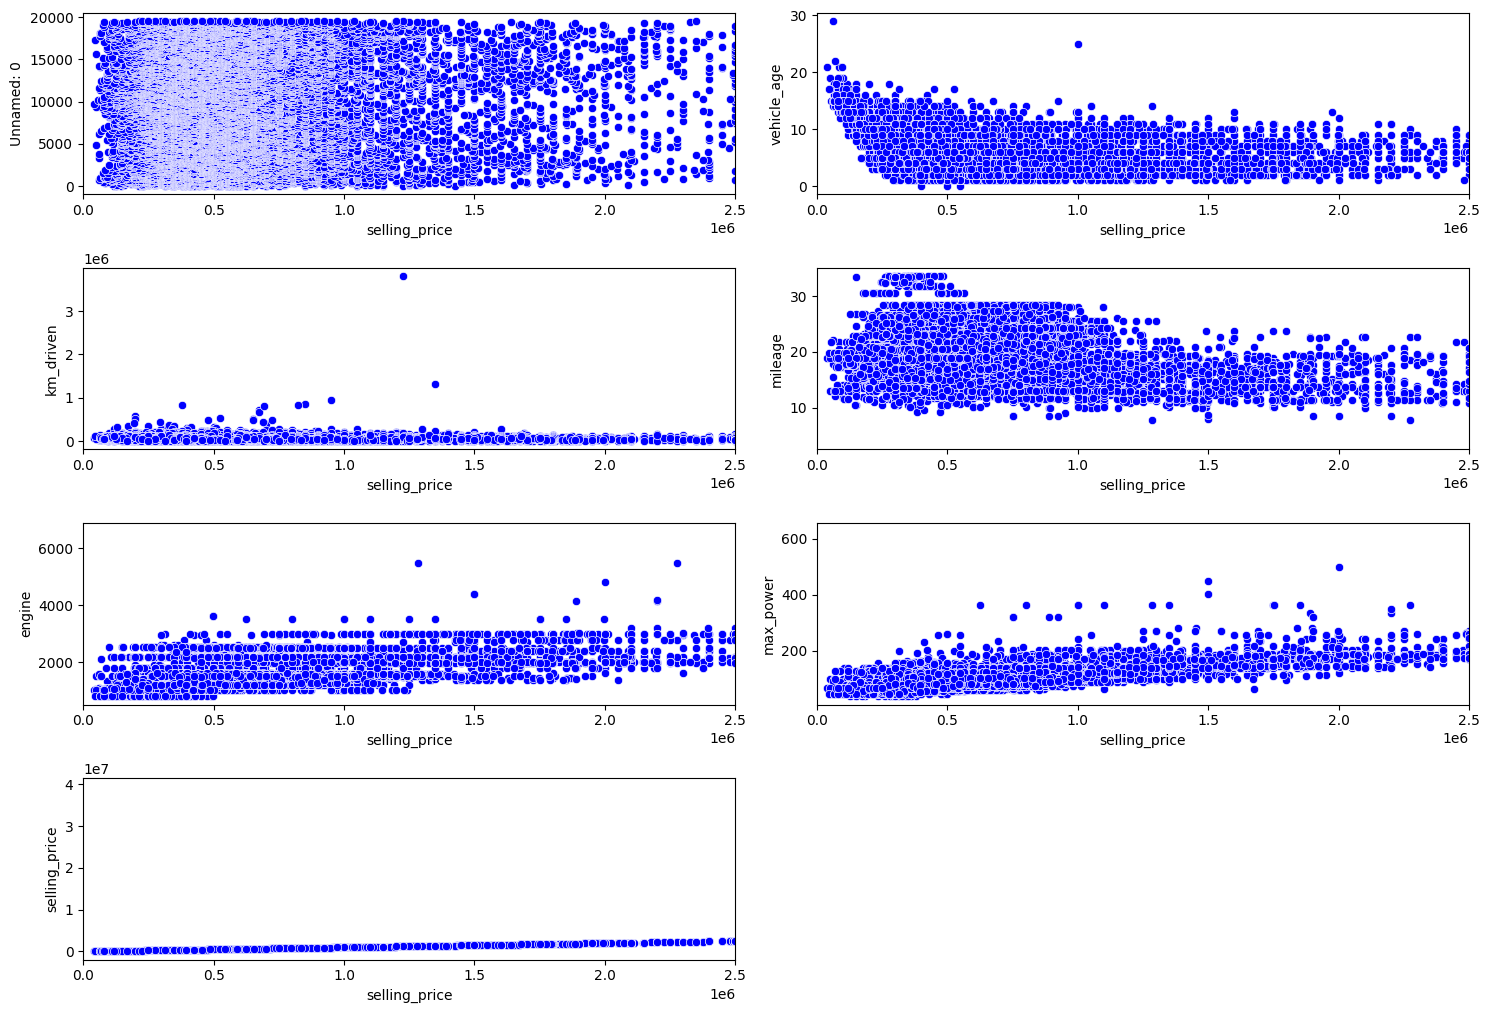

In [101]:
fig = plt.figure(figsize=(15,20))

for i in range(0, len(continuous_features)):
    ax = plt.subplot(8, 2, i+1)

    sns.scatterplot(data = car, x='selling_price', y = continuous_features[i], color='b')
    plt.xlim(0,2500000)
    plt.tight_layout()

# Multivariant analysis

## Correlation Analysis

In this step, we compute the correlation between all numerical features in the dataset using the `corr()` function.

Correlation helps us understand the relationship between variables:
- Positive correlation → both variables increase together  
- Negative correlation → one variable increases while the other decreases  
- Zero or near-zero correlation → no linear relationship  

This analysis is important to identify which features are strongly related to the target variable (`selling_price`) and to detect multicollinearity between features before building the machine learning model.

In [102]:
car[num_cols].corr()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
Unnamed: 0,1.000000,-0.006250,-0.003778,-0.014699,0.012972,0.039367,-0.031832,0.030523
vehicle_age,-0.006250,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,-0.003778,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830,-0.080030
mileage,-0.014699,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.012972,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,0.039367,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,-0.031832,0.030791,0.192830,-0.440280,0.551236,0.172257,1.000000,0.115033
selling_price,0.030523,-0.241851,-0.080030,-0.305549,0.585844,0.750236,0.115033,1.000000


## Correlation Heatmap Visualization

In this step, we visualize the correlation between numerical features using a heatmap.

We use seaborn’s `heatmap()` to display the correlation matrix in a graphical format.

This helps us:
- Easily identify strong positive or negative relationships between features  
- Understand which variables are highly correlated with each other  
- Detect multicollinearity issues that may affect model performance  

The color intensity represents the strength of correlation, making it easier to interpret relationships between variables at a glance.

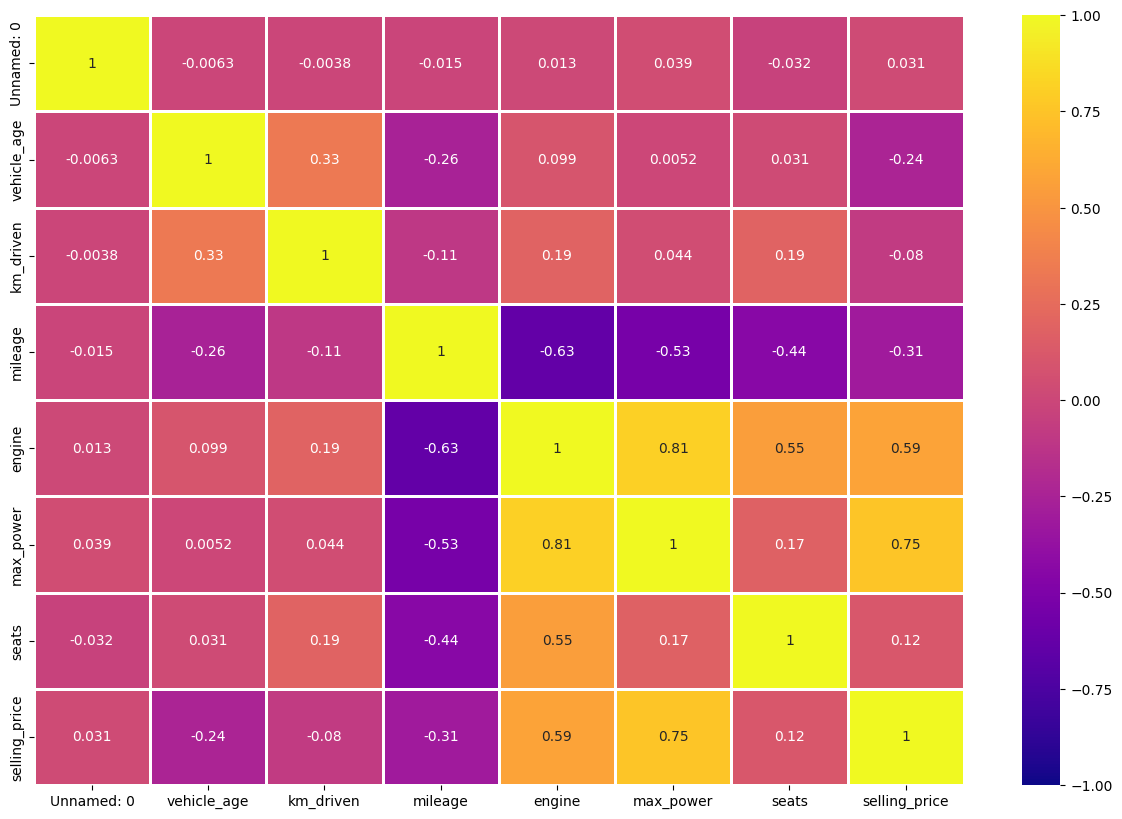

In [103]:
plt.figure(figsize=(15,10))
sns.heatmap(data=car[num_cols].corr(),annot=True,cmap='plasma', vmin=-1, vmax=1, linecolor='white',linewidths=2)
plt.show()

## Chi-Square Test for Categorical Variables

In this step, we perform the Chi-Square test to analyze the relationship between two categorical variables: `fuel_type` and `transmission_type`.

We create a contingency table using `pd.crosstab()` and then apply the Chi-Square test using `chi2_contingency`.

This test helps us determine:
- Whether there is a significant relationship between the two categorical features  
- Whether the variables are independent or dependent  

We interpret the result using the p-value:
- If p-value < 0.05 → variables are dependent (significant relationship exists)  
- If p-value ≥ 0.05 → variables are independent (no significant relationship)  

In [104]:
from scipy.stats import chi2_contingency

# 1. Create the contingency table
# Example: Relationship between 'fuel_type' and 'transmission_type'
contingency_table = pd.crosstab(car['fuel_type'], car['transmission_type'])

# 2. Run the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p}")

Chi-Square Statistic: 114.3379133621549
P-value: 8.640300591160017e-24


# Insights from data visualization

## Distribution of Selling Price

In this step, we visualize the distribution of the target variable `selling_price` using a histogram with a kernel density estimation (KDE) curve.

This helps us understand:
- How selling prices are distributed across the dataset  
- Whether the data is skewed or normally distributed  
- The frequency of different price ranges  

We also limit the x-axis range to focus on the majority of data and reduce the impact of extreme outliers. This gives a clearer view of the overall price distribution pattern.

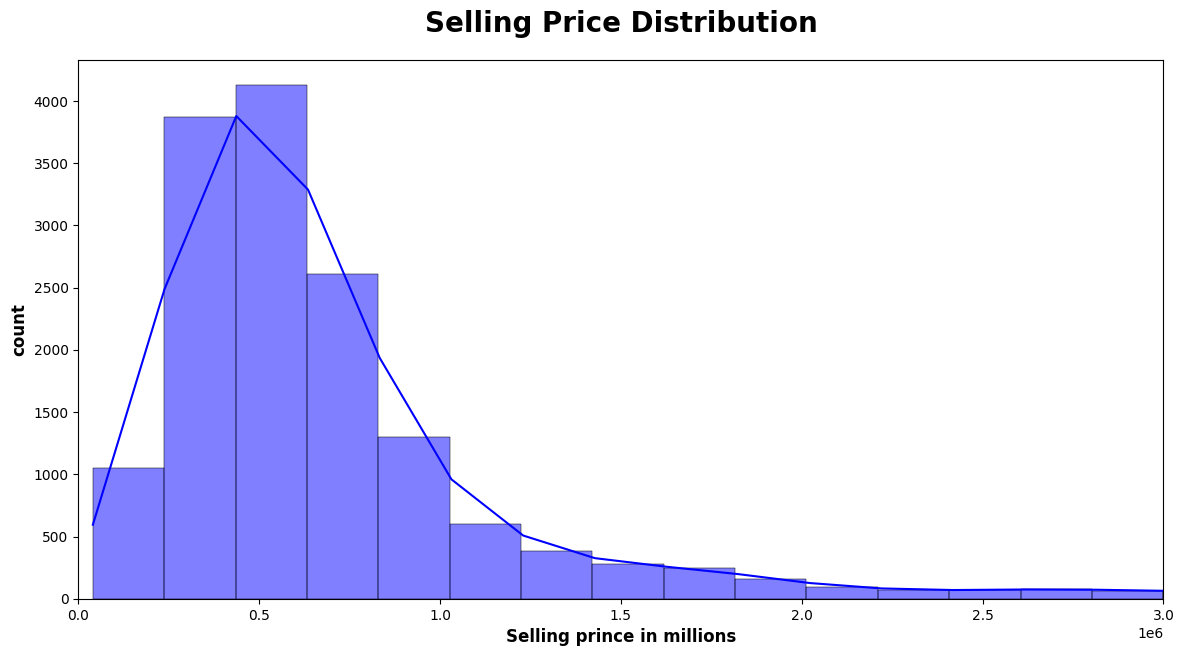

In [26]:
plt.subplots(figsize=(14,7))
sns.histplot(car.selling_price, bins=200, kde=True, color='b')
plt.title("Selling Price Distribution", weight="bold", fontsize=20, pad=20)
plt.ylabel("count",weight='bold', fontsize=12)
plt.xlabel("Selling prince in millions", weight="bold", fontsize=12)
plt.xlim(0,3000000)
plt.show()

## Top Selling Cars Analysis

In this step, we analyze the most frequently sold cars in the dataset based on the `car_name` column.

We use `value_counts()` to count the occurrences of each car model and then extract the top 10 most sold cars.

This helps us understand:
- Which car models are most popular in the used car market  
- Customer preference trends on the CarDekho platform  
- Demand distribution across different car names  

This insight is useful for understanding market trends and identifying high-demand vehicles.

In [27]:
print('_'*50)
print("Top 10 sold car on cardekho website")
print('_'*50)

car.car_name.value_counts()[0:10]

__________________________________________________
Top 10 sold car on cardekho website
__________________________________________________


car_name
Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Maruti Alto           778
Honda City            757
Maruti Wagon R        717
Hyundai Grand         580
Toyota Innova         545
Hyundai Verna         492
Hyundai i10           410
Name: count, dtype: int64

## Top 10 Most Sold Cars Visualization

In this step, we visualize the top 10 most frequently sold cars using a count plot.

We use seaborn’s `countplot()` to display the frequency of each car model based on the `car_name` column.

This visualization helps us:
- Clearly identify the most popular car models in the dataset  
- Understand demand patterns in the used car market  
- Compare the sales distribution among top car names  

We also rotate the x-axis labels for better readability and limit the view to focus only on the top 10 cars for clearer analysis.

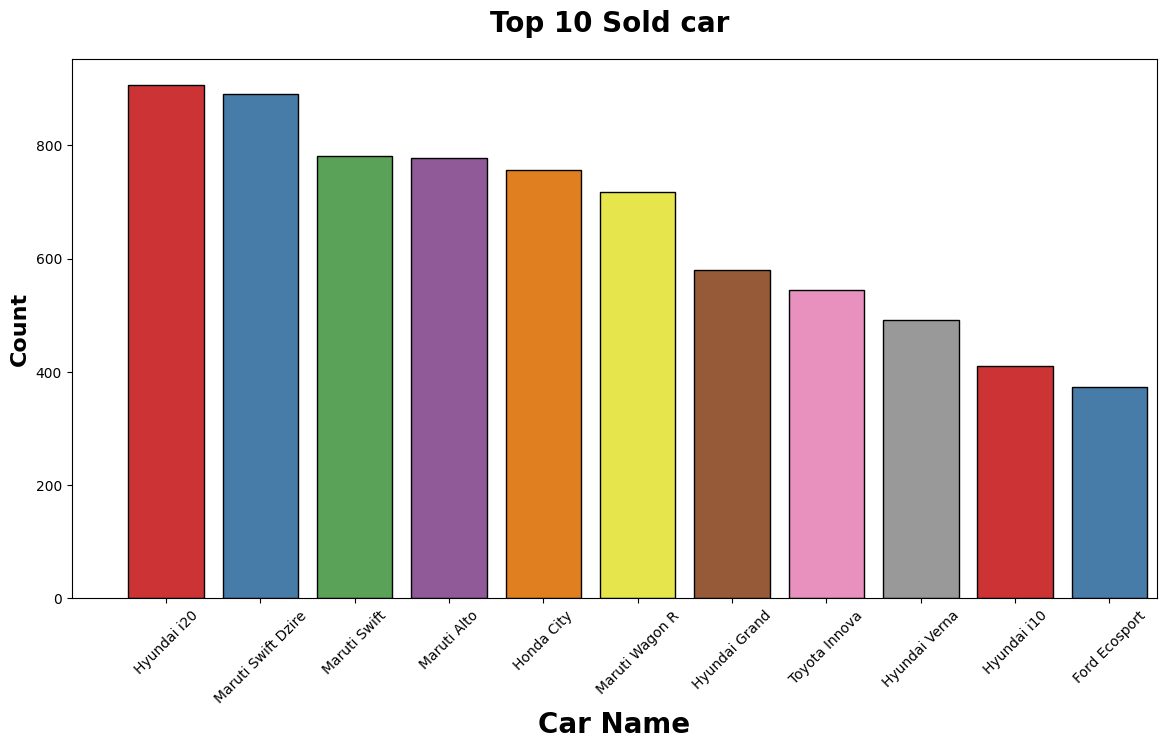

In [28]:
plt.subplots(figsize=(14,7))
sns.countplot(x="car_name", data=car,ec = "black", palette="Set1",order=car['car_name'].value_counts().index)
plt.title("Top 10 Sold car ",weight="bold", fontsize=20,pad=20)
plt.xlabel("Car Name", weight="bold", fontsize=20)
plt.ylabel("Count", weight="bold",fontsize=16)
plt.xticks(rotation=45)
plt.xlim(-1,10.5)
plt.show()

## Average Selling Price Analysis for a Specific Car Model

In this step, we calculate the average selling price of a specific car model (Hyundai i20) from the dataset.

We filter the dataset using the condition `car_name == 'Hyundai i20'` and then compute the mean of the `selling_price` column.

This helps us understand:
- The average market price of a specific car model  
- How different models vary in price within the dataset  
- Useful insights for comparing pricing between car brands and models  

Such analysis is helpful for understanding model-wise pricing trends in the used car market.

In [29]:
i20 = car[car['car_name']== 'Hyundai i20']['selling_price'].mean()
print(f'The mean price of hyundai i120 is {i20:.2f} Rupees')

The mean price of hyundai i120 is 543603.75 Rupees


## Top Brands Analysis

In this step, we analyze the most frequently sold car brands in the dataset.

We use `value_counts()` on the `brand` column and extract the top 10 brands with the highest number of occurrences.

This helps us understand:
- Which car brands are most popular in the used car market  
- Customer preference trends across different manufacturers  
- Market dominance of specific brands  

This insight is useful for identifying high-demand brands and understanding overall market trends in the dataset.

In [30]:
print('_'*50)
print("Top 10 brands sold")
print('_'*50)

# This is the cleanest version
print(car['brand'].value_counts().head(10))

__________________________________________________
Top 10 brands sold
__________________________________________________
brand
Maruti        4992
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            439
Tata           430
Name: count, dtype: int64


## Top 10 Car Brands Visualization

In this step, we visualize the top 10 most sold car brands using a count plot.

We use seaborn’s `countplot()` to display the frequency of each brand based on the `brand` column in the dataset.

This helps us understand:
- The most popular car brands in the used car market  
- Brand-wise demand distribution  
- Comparative popularity among top manufacturers  

We also rotate the x-axis labels for better readability and focus only on the top 10 brands for clearer visualization of dominant brands.

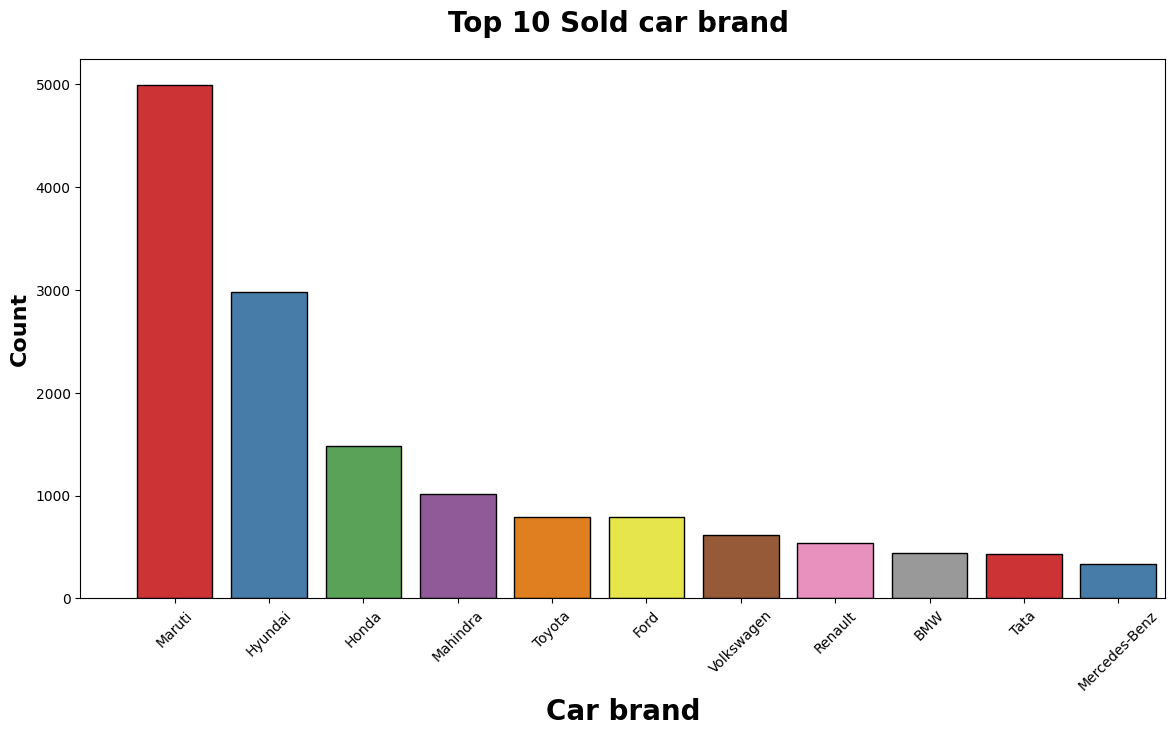

In [31]:
plt.subplots(figsize=(14,7))
sns.countplot(x="brand", data=car,ec = "black", palette="Set1",order=car['brand'].value_counts().index)
plt.title("Top 10 Sold car brand ",weight="bold", fontsize=20,pad=20)
plt.xlabel("Car brand", weight="bold", fontsize=20)
plt.ylabel("Count", weight="bold",fontsize=16)
plt.xticks(rotation=45)
plt.xlim(-1,10.5)
plt.show()

## Average Selling Price Analysis for Maruti Cars

In this step, we calculate the average selling price of cars belonging to the brand "Maruti" from the dataset.

We filter the dataset using the condition `brand == 'Maruti'` and then compute the mean of the `selling_price` column.

This helps us understand:
- The average market price of Maruti cars in the used car dataset  
- Pricing trends specific to a popular car brand  
- Comparison of brand-wise average selling prices  

Such analysis is useful for understanding how different brands perform in the used car market in terms of pricing.

In [32]:
mar = car[car['brand']== 'Maruti']['selling_price'].mean()
print(f'The mean price of hyundai i120 is {mar:.2f} Rupees')

The mean price of hyundai i120 is 487089.32 Rupees


## Average Price Analysis of Car Brands

In this step, we analyze the average selling price of each car brand in the dataset.

We group the data by the `brand` column and calculate the mean of the `selling_price` for each group. The results are then sorted in descending order to identify the most expensive brands on average.

This analysis helps us understand:
- Which car brands have the highest average resale value  
- Brand-wise pricing hierarchy in the used car market  
- Market positioning of different manufacturers  

This insight is useful for comparing luxury vs budget brands and understanding overall pricing trends across brands.

In [33]:
brand_prices = car.groupby('brand')['selling_price'].mean().sort_values(ascending=False)

# Display the Top 5 most expensive brands on average
print('_'*50)
print("Costliest Brands (Average Price):")
print('_'*50)
brand_prices

__________________________________________________
Costliest Brands (Average Price):
__________________________________________________


brand
Ferrari          3.950000e+07
Rolls-Royce      2.420000e+07
Bentley          9.266667e+06
Maserati         6.100000e+06
Porsche          5.161190e+06
Lexus            5.146500e+06
Mercedes-AMG     5.100000e+06
Land Rover       3.823902e+06
Volvo            3.729700e+06
BMW              2.693827e+06
Jaguar           2.643034e+06
Mercedes-Benz    2.480742e+06
Mini             2.182647e+06
Audi             1.966865e+06
ISUZU            1.897500e+06
Jeep             1.795805e+06
MG               1.752947e+06
Kia              1.735250e+06
Toyota           1.371317e+06
Isuzu            1.355000e+06
Nissan           9.553636e+05
Mahindra         7.874550e+05
Skoda            7.840898e+05
Force            7.000000e+05
Tata             6.835349e+05
Ford             6.452241e+05
Honda            6.177569e+05
Hyundai          5.761539e+05
Volkswagen       5.165468e+05
Maruti           4.870893e+05
Renault          4.409851e+05
Datsun           3.205176e+05
Name: selling_price, dtype: float6

## Visualization of Average Car Brand Prices

In this step, we visualize the average selling price of the top car brands using a bar plot.

We use seaborn’s `barplot()` to represent the average price of each brand calculated earlier.

This visualization helps us understand:
- Which car brands have higher average resale value  
- Price differences across different manufacturers  
- Overall brand-wise market positioning  

We also rotate the x-axis labels for better readability since brand names may overlap, and we present the data in a clear comparative format.

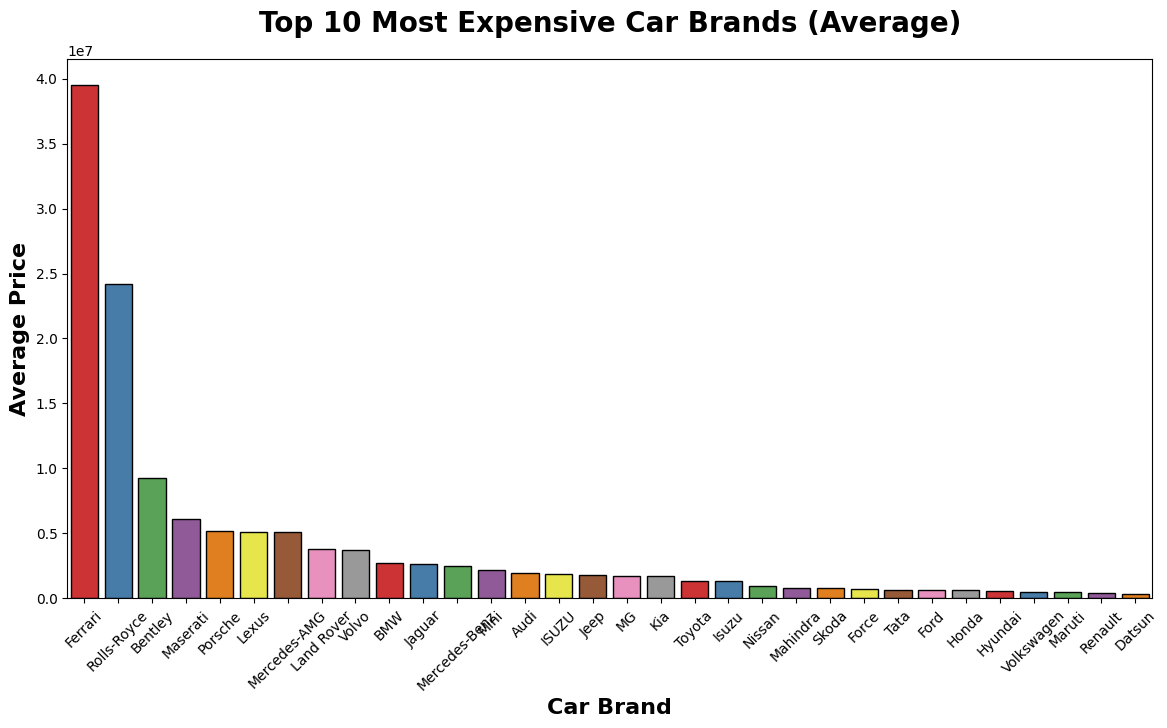

In [34]:
plt.subplots(figsize=(14,7))
sns.barplot(x=brand_prices.index, y=brand_prices.values, ec="black", palette="Set1")

plt.title("Top 10 Most Expensive Car Brands (Average)", weight="bold", fontsize=20, pad=20)
plt.xlabel("Car Brand", weight="bold", fontsize=16)
plt.ylabel("Average Price", weight="bold", fontsize=16)
plt.xticks(rotation=45)
plt.show()

## Brand-wise Mileage Analysis

In this step, we analyze the average mileage of each car brand in the dataset.

We group the data by `brand` and calculate the mean of the `mileage` column. The results are then sorted in descending order to identify the brands that offer the highest fuel efficiency on average.

This helps us understand:
- Which car brands provide better mileage  
- Fuel efficiency comparison across different manufacturers  
- Practical insights for cost-effective car selection  

Finally, the results are converted into a DataFrame format for better readability and presentation.

In [35]:
mileage = car.groupby('brand')['mileage'].mean().sort_values(ascending=False)

# Display the Top 5 most expensive brands on average
print('_'*50)
print("Most mileage car brand on cardekho website:")
print('_'*50)

mileage.to_frame()

__________________________________________________
Most mileage car brand on cardekho website:
__________________________________________________


,mileage
brand,
Maruti,22.430980
Renault,22.099142
Datsun,21.215647
Lexus,20.846000
Ford,19.922620
Honda,19.908795
Maserati,19.820000
Tata,19.755279
Hyundai,19.588776


## Brand-wise Mileage Visualization

In this step, we visualize the average mileage of the top 10 car brands using a bar plot.

We use seaborn’s `barplot()` to compare the fuel efficiency (mileage in kmpl) across different brands.

This helps us understand:
- Which car brands offer the best fuel efficiency  
- Comparison of mileage performance among top brands  
- Practical insights for users looking for fuel-efficient cars  

We focus on the top 10 brands for clearer visualization and rotate the x-axis labels for better readability.

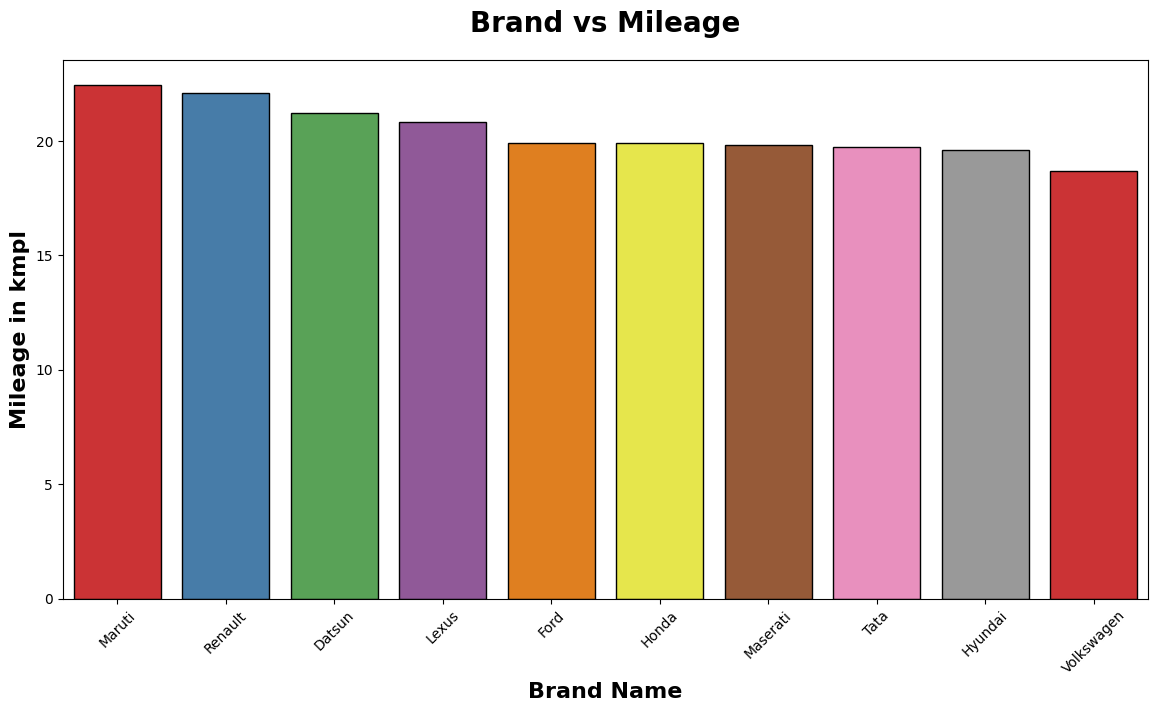

In [112]:
plt.subplots(figsize=(14,7))
sns.barplot(x=mileage.index[:10], y=mileage.values[:10], ec="black", palette="Set1")

plt.title("Brand vs Mileage", weight="bold", fontsize=20, pad=20)
plt.xlabel("Brand Name", weight="bold", fontsize=16)
plt.ylabel("Mileage in kmpl", weight="bold", fontsize=16)
plt.xticks(rotation=45)
plt.show()

In [37]:
fuel = car.groupby('fuel_type')['selling_price'].median().sort_values(ascending=False)
fuel.to_frame()

,selling_price
fuel_type,
Electric,1857500.0
Diesel,700000.0
Petrol,460000.0
CNG,370000.0
LPG,182500.0


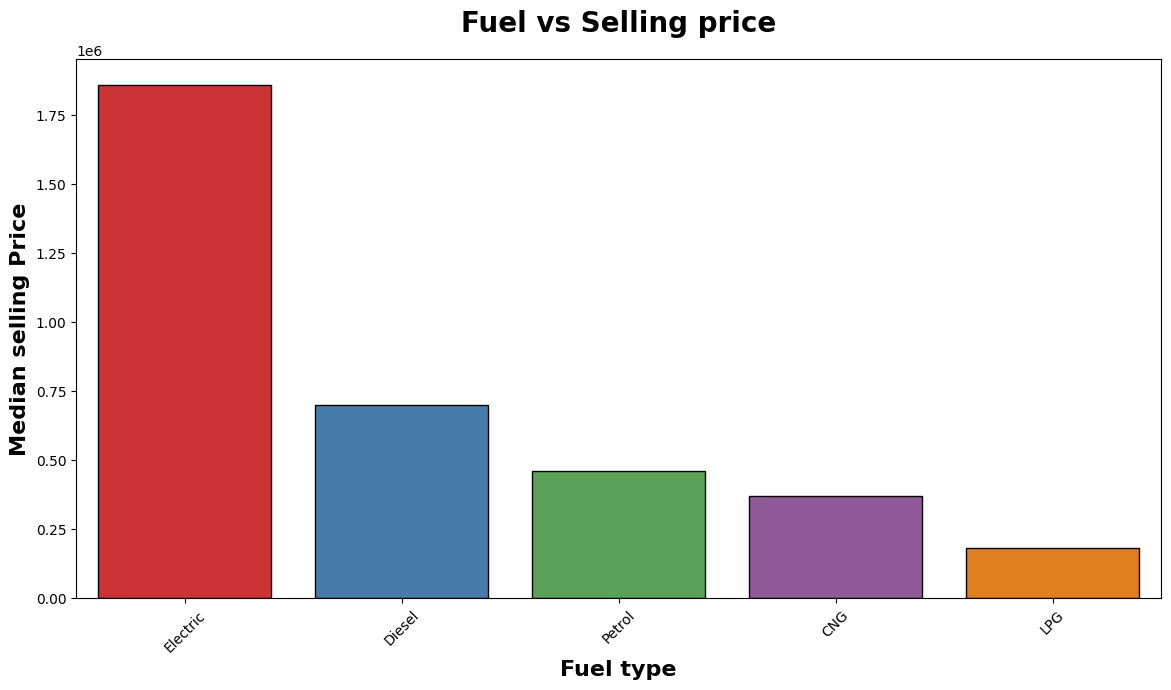

In [39]:
plt.subplots(figsize=(14,7))
sns.barplot(x=fuel.index, y=fuel.values, ec="black", palette="Set1")

plt.title("Fuel vs Selling price", weight="bold", fontsize=20, pad=20)
plt.xlabel("Fuel type", weight="bold", fontsize=16)
plt.ylabel("Median selling Price", weight="bold", fontsize=16)
plt.xticks(rotation=45)
plt.show()

## Comprehensive Analysis of Key Features and Their Relationship with Price

In this step, we perform detailed exploratory data analysis (EDA) to understand how different features influence the selling price of cars. We use various visualizations such as scatter plots, histograms, line plots, boxplots, and count plots to analyze relationships and distributions in the dataset.

---

### 1. Mileage vs Selling Price
We use a scatter plot to analyze the relationship between mileage and selling price, with color coding based on fuel type. This helps us understand how fuel efficiency and fuel type affect car prices.

---

### 2. Mileage Distribution
We use a histogram with KDE (Kernel Density Estimation) to visualize how mileage values are distributed in the dataset. This helps identify common mileage ranges and data spread.

---

### 3. Vehicle Age vs Selling Price
We use a line plot to study how car age affects selling price. This helps us understand depreciation trends in used cars.

---

### 4. Vehicle Age vs Mileage
We use a boxplot to analyze how mileage varies with vehicle age. This helps us understand how usage changes as cars get older.

---

### 5. Oldest Cars in Dataset
We group the dataset by car name and find the maximum vehicle age for each model. This helps identify which car models have been in use for the longest time.

---

### 6. Transmission Type Analysis
We use a count plot to understand the distribution of transmission types (Manual vs Automatic). We also analyze how transmission type affects selling price using a bar plot.

---

### 7. Seller Type Analysis
We use a count plot to analyze seller types (Dealer vs Individual). This helps us understand the source distribution of car listings in the dataset.

---

## Key Insights:
- Higher mileage generally leads to lower selling prices  
- Diesel and petrol cars show different pricing patterns  
- Older cars tend to depreciate in value  
- Manual transmission cars are more common than automatic cars  
- Automatic cars generally have higher selling prices  
- Dealer listings dominate compared to individual sellers  
- Mileage and age together strongly influence car pricing trends  

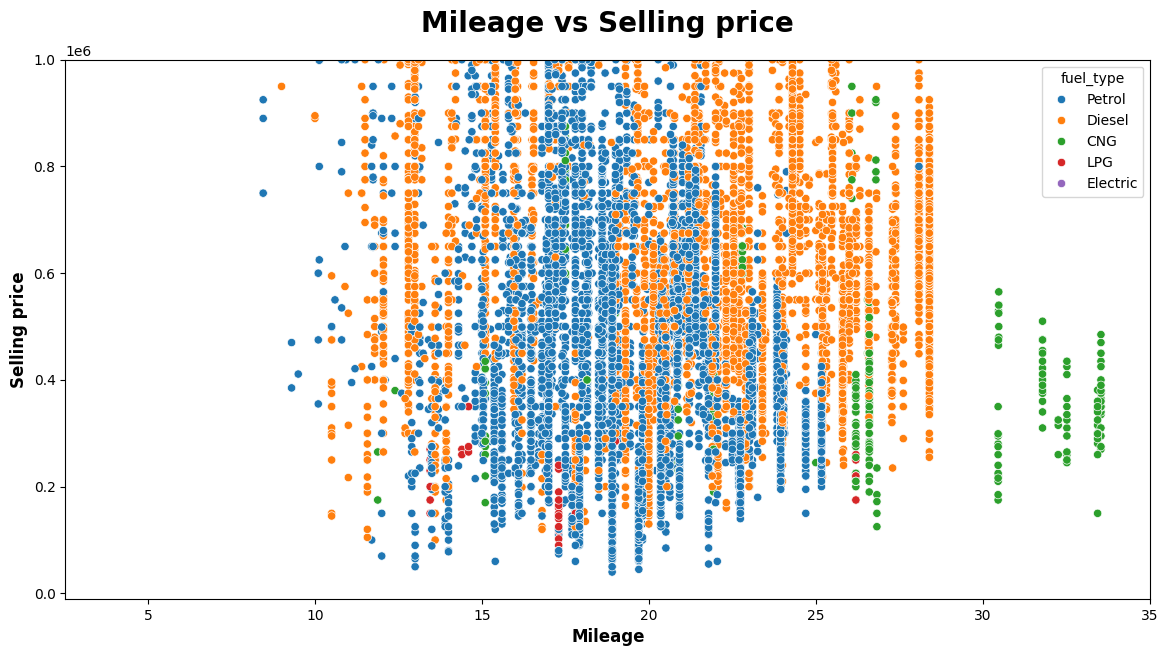

In [40]:
plt.subplots(figsize=(14,7))
sns.scatterplot(x="mileage", y="selling_price", data=car, color='b', hue="fuel_type")
plt.title("Mileage vs Selling price", weight="bold", fontsize=20, pad=20)
plt.ylabel("Selling price",weight='bold', fontsize=12)
plt.xlabel("Mileage", weight="bold", fontsize=12)
plt.ylim(-10000,1000000)
plt.show()

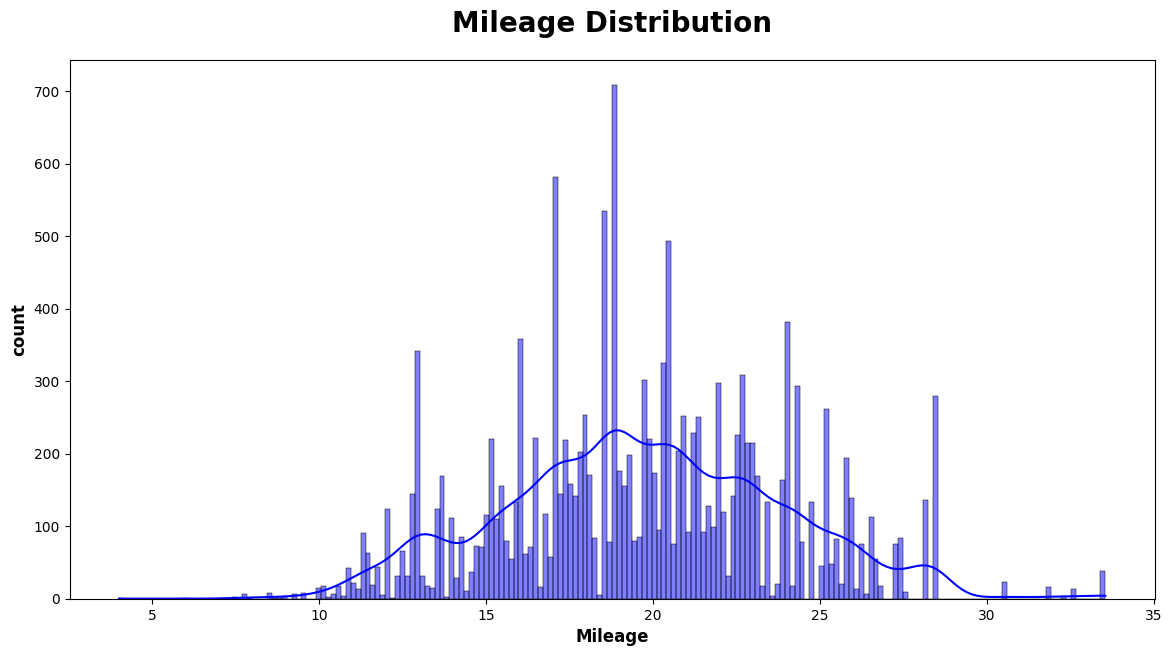

In [41]:
plt.subplots(figsize=(14,7))
sns.histplot(car.mileage, bins=200, kde=True, color='b')
plt.title("Mileage Distribution", weight="bold", fontsize=20, pad=20)
plt.ylabel("count",weight='bold', fontsize=12)
plt.xlabel("Mileage", weight="bold", fontsize=12)
plt.show()

In [42]:
num_cols

Index(['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='str')

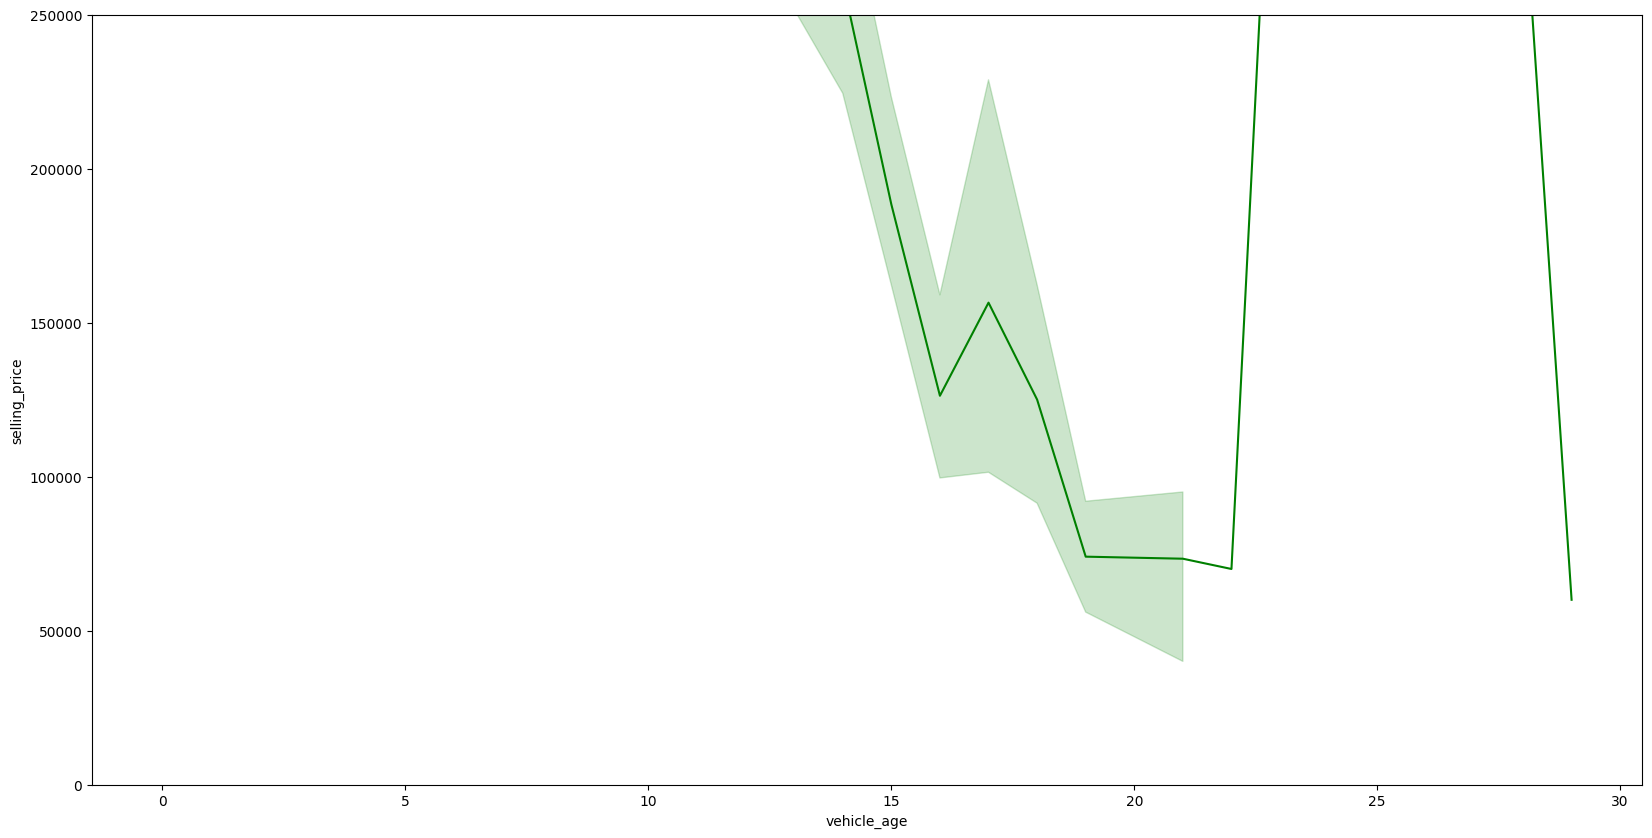

In [43]:
plt.subplots(figsize=(20,10))
sns.lineplot(x='vehicle_age',y='selling_price',data=car,color='g')
plt.ylim(0,250000)
plt.show()

In [44]:
vech_age = car.groupby('vehicle_age')['mileage'].median().sort_values(ascending=False)
vech_age.to_frame().head(5)

,mileage
vehicle_age,
29,22.05
0,21.70
3,21.21
4,20.63
5,20.51


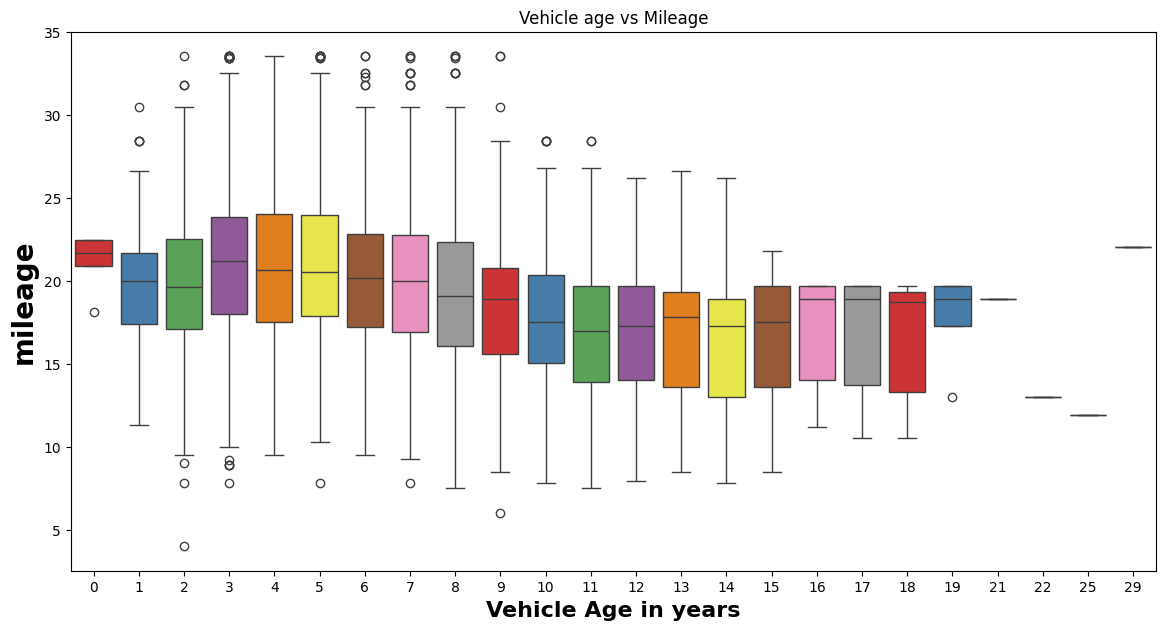

In [45]:
plt.subplots(figsize=(14,7))
sns.boxplot(x=car.vehicle_age,y=car.mileage,palette='Set1')
plt.title("Vehicle age vs Mileage")
plt.xlabel("Vehicle Age in years", weight="bold",fontsize=16)
plt.ylabel("mileage", weight="bold",fontsize=20)
plt.show()

In [46]:
old_age = car.groupby('car_name')['vehicle_age'].max().sort_values(ascending=False)
old_age.to_frame().head(10)

,vehicle_age
car_name,
Maruti Alto,29
BMW 3,25
Honda City,22
Maruti Wagon R,21
Mahindra Scorpio,18
Mahindra Bolero,18
Skoda Octavia,18
Mercedes-Benz E-Class,17
Honda CR-V,17


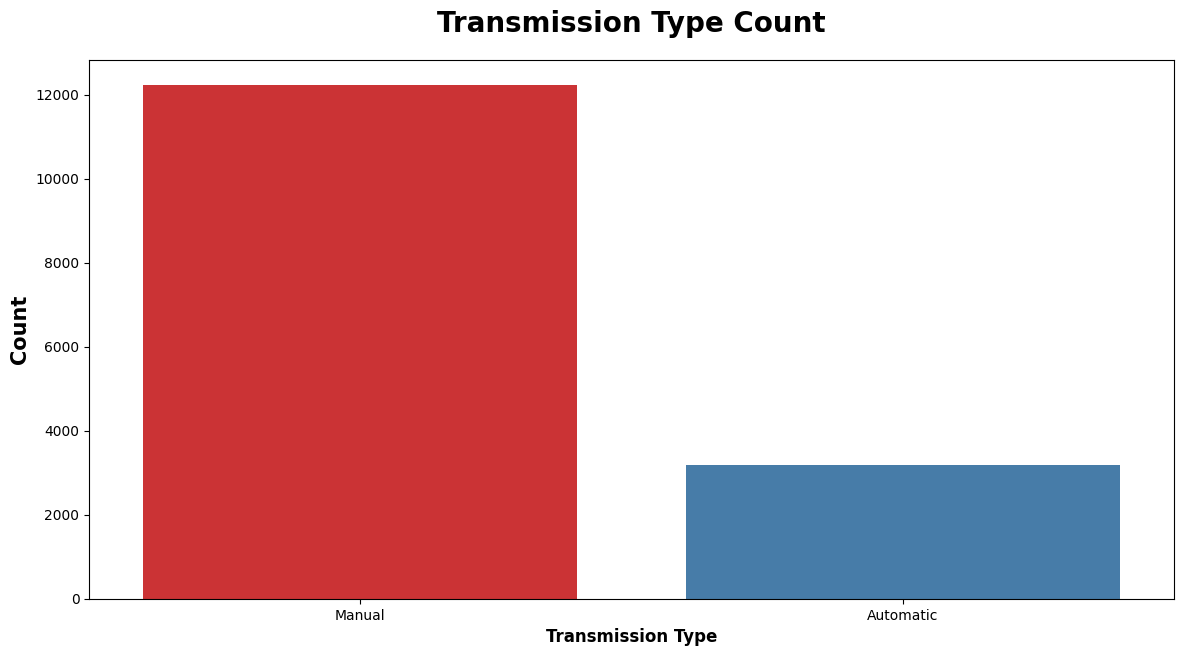

In [47]:
plt.subplots(figsize=(14,7))
sns.countplot(x='transmission_type', data=car, palette="Set1")
plt.title("Transmission Type Count", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count",weight="bold",fontsize=15)
plt.xlabel("Transmission Type",weight="bold",fontsize=12)
plt.show()

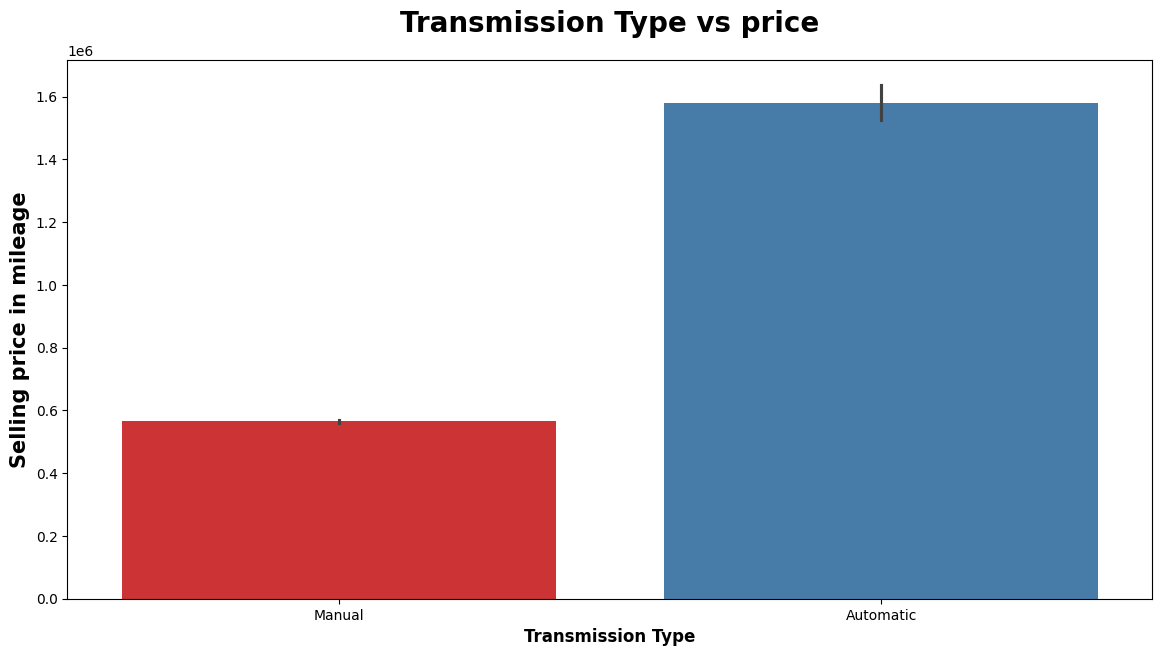

In [48]:
plt.subplots(figsize=(14,7))
sns.barplot(x='transmission_type',y="selling_price", data=car, palette="Set1")
plt.title("Transmission Type vs price", weight="bold", fontsize=20, pad=20)
plt.ylabel("Selling price in mileage",weight="bold",fontsize=15)
plt.xlabel("Transmission Type",weight="bold",fontsize=12)
plt.show()

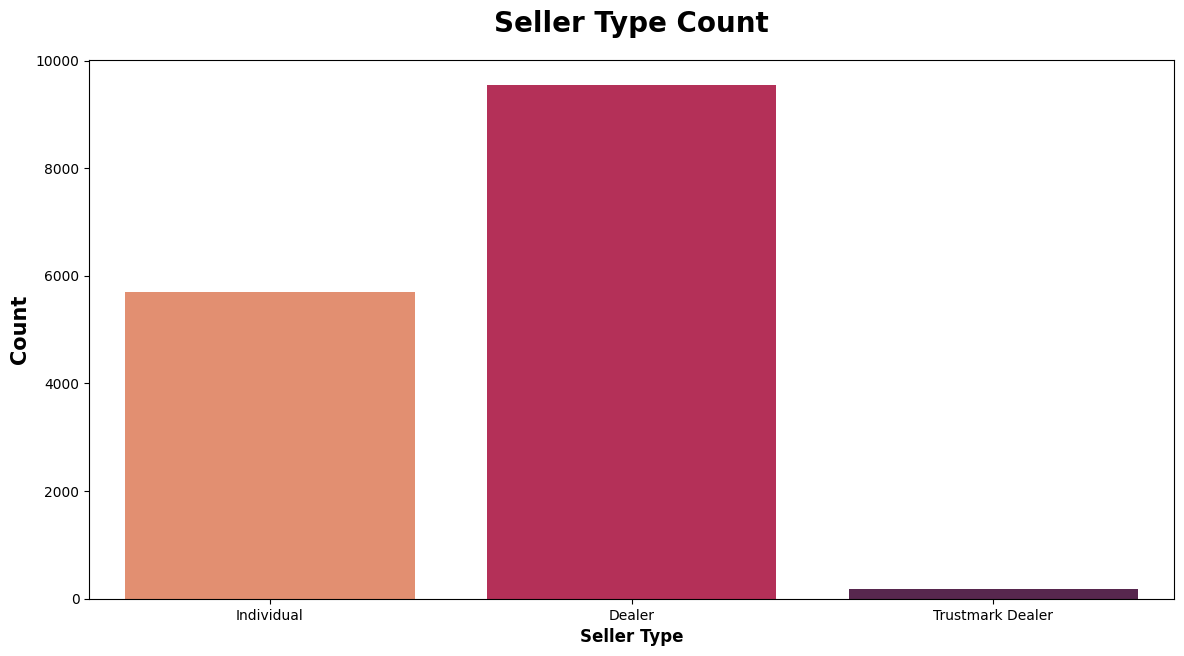

In [49]:
plt.subplots(figsize=(14,7))
sns.countplot(x='seller_type', data=car, palette="rocket_r")
plt.title("Seller Type Count", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count",weight="bold",fontsize=15)
plt.xlabel("Seller Type",weight="bold",fontsize=12)
plt.show()

In [50]:
dealer_type = car.groupby('seller_type')['selling_price'].median().sort_values(ascending=True)
dealer_type.to_frame()

,selling_price
seller_type,
Individual,507000.0
Trustmark Dealer,540000.0
Dealer,591000.0


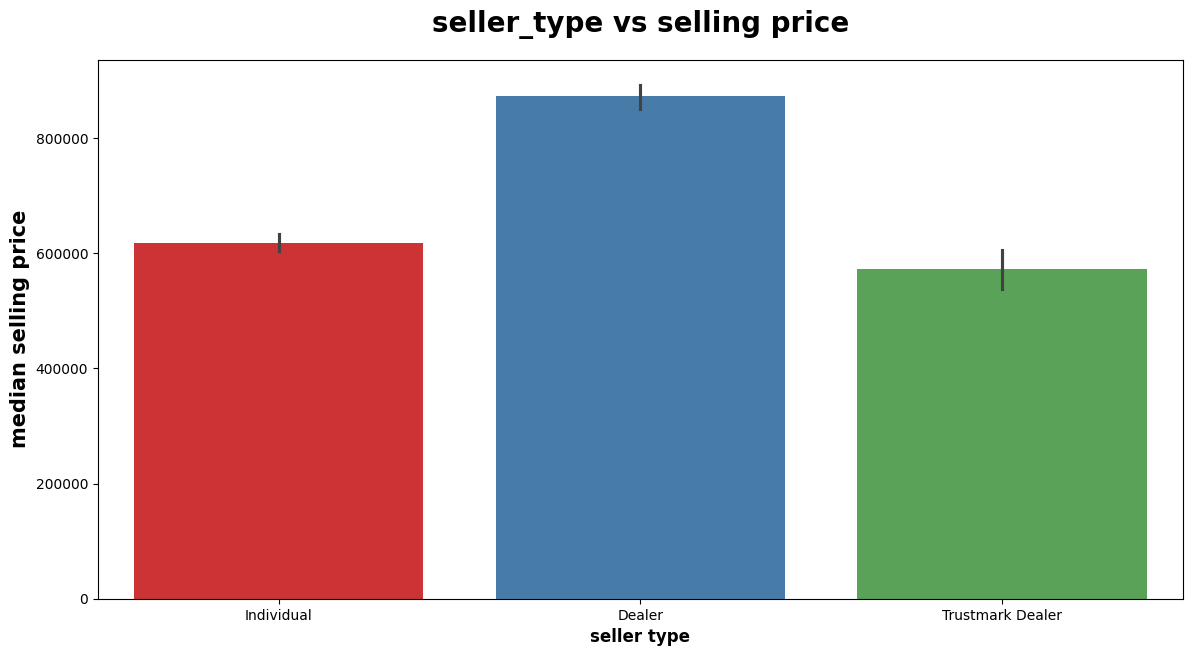

In [51]:
plt.subplots(figsize=(14,7))
sns.barplot(x='seller_type',y="selling_price", data=car, palette="Set1")
plt.title("seller_type vs selling price", weight="bold", fontsize=20, pad=20)
plt.ylabel("median selling price",weight="bold",fontsize=15)
plt.xlabel("seller type",weight="bold",fontsize=12)
plt.show()

# Feature Engineering

In [52]:
df_model = car.copy()
df_model

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


## Remove the unnecessary feature
Dropping car_name, brand and model

In [53]:
df_model.drop(labels=['Unnamed: 0', 'car_name','brand','model'], axis=1,inplace=True)

In [54]:
df_model

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [55]:
df_model.dtypes

vehicle_age            int64
km_driven              int64
seller_type              str
fuel_type                str
transmission_type        str
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [56]:
df_model = pd.get_dummies(df_model,dtype=float)
df_model

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,5,20000,18.90,1197,82.00,5,550000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,11,60000,17.00,1197,80.00,5,215000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,9,37000,20.92,998,67.10,5,226000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,6,30000,22.77,1498,98.59,5,570000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,250000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15407,2,18000,17.50,1373,91.10,7,925000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15408,6,67000,21.14,1498,103.52,5,425000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
15409,5,3800000,16.00,2179,140.00,7,1225000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


# Creating feature matrix (independent variable) & Target variable (Dependent variable)

In [60]:
X = df_model.drop(labels=['selling_price'],axis=1)
X

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,5,20000,18.90,1197,82.00,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,11,60000,17.00,1197,80.00,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,9,37000,20.92,998,67.10,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,6,30000,22.77,1498,98.59,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15407,2,18000,17.50,1373,91.10,7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15408,6,67000,21.14,1498,103.52,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
15409,5,3800000,16.00,2179,140.00,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [61]:
y = df_model['selling_price']
y

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
15406     250000
15407     925000
15408     425000
15409    1225000
15410    1200000
Name: selling_price, Length: 15411, dtype: int64

# Checking the feature importance

In [62]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor()

print(model.fit(X,y))

ExtraTreesRegressor()


In [63]:
print('_' *50)
print("checking for feature importance")
print('_'*50)

print(model.feature_importances_)

__________________________________________________
checking for feature importance
__________________________________________________
[1.70207785e-01 4.87002159e-02 6.28281583e-02 1.43533620e-01
 3.67317241e-01 1.52297481e-02 3.10543311e-03 3.92163443e-03
 2.32025323e-05 3.99435993e-05 7.91996371e-03 8.08700827e-06
 3.09091916e-06 2.39705872e-02 7.59194568e-02 7.72718328e-02]


## visulization for feature importance

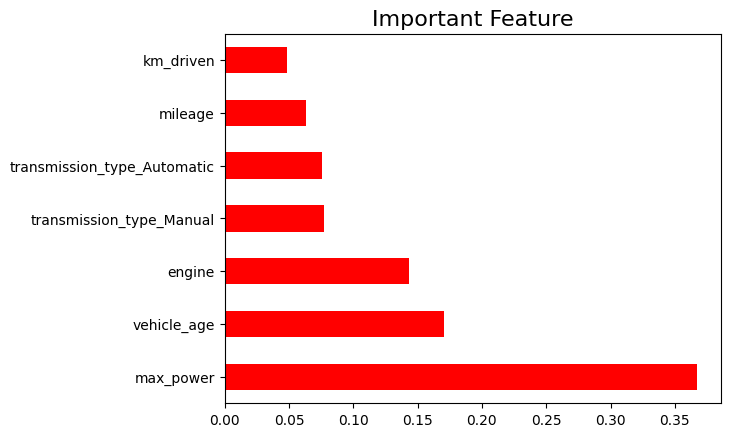

In [64]:
imp_feature = pd.Series(model.feature_importances_,index= X.columns)
imp_feature.nlargest(7).plot(kind='barh', color='red')
plt.title("Important Feature", fontsize=16)
plt.show()

# Model Build

In [65]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2, random_state=3)

## Importing important libraries for model building

In [66]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,explained_variance_score,r2_score

In [67]:
models = [LinearRegression, SVR, DecisionTreeRegressor, RandomForestRegressor, Ridge, Lasso]
mse=[]
rmse=[]
evs=[]
r_square_error =[]

for model in models:
    regressor = model().fit(X_train,y_train)
    pred= regressor.predict(X_test)
    mse.append(mean_squared_error(y_true=y_test,y_pred= pred))
    rmse.append(np.sqrt(mean_squared_error(y_true=y_test,y_pred= pred)))
    evs.append(explained_variance_score(y_true=y_test,y_pred= pred))
    r_square_error.append(r2_score(y_true=y_test,y_pred= pred))

# Creating Data Frame for model comparison

In [68]:
ML_mode_df = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Decision Tree Regressor", "Random forest Regressor", "Ridge", "Lasso"],
    "Mean Squared Error": mse,
    "Root Mean Squared Error": rmse,
    "Explained Variance Score": evs,
    "R-Square Score(Accuracy)": r_square_error
})

# Set index using the corrected column name 'Model'
ML_mode_df.set_index('Model', inplace=True)

ML_mode_df.reset_index()

,Model,Mean Squared Error,Root Mean Squared Error,Explained Variance Score,R-Square Score(Accuracy)
0,Linear Regression,2.185960e+11,467542.539990,0.685279,0.685090
1,Support Vector Regression,7.409353e+11,860776.003232,0.000099,-0.067394
2,Decision Tree Regressor,1.187481e+11,344598.526579,0.828932,0.828931
3,Random forest Regressor,4.678325e+10,216294.356340,0.932651,0.932604
4,Ridge,2.185927e+11,467538.986504,0.685284,0.685095
5,Lasso,2.185952e+11,467541.653847,0.685280,0.685091


In [69]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, explained_variance_score,r2_score
import numpy as np

In [70]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt', 'log2'], # 'auto' changed to 1.0
    'bootstrap': [True, False]
}

rf = RandomForestRegressor()
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=100,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


In [71]:
 #Run the search
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': [1.0, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [72]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)


In [73]:
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
evs_rf = explained_variance_score(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)

In [74]:
mse.append(mse_rf)
rmse.append(rmse_rf)
evs.append(evs_rf)
r_square_error.append(r2_rf) # Using the name from your DataFrame step

In [75]:
print("-" * 30)
print(f"Best Parameters: {random_search.best_params_}")
print(f"MSE: {mse_rf}")
print(f"RMSE: {rmse_rf}")
print(f"EVS: {evs_rf}")
print(f"R2 Score: {r2_rf}")

------------------------------
Best Parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 30, 'bootstrap': True}
MSE: 47553741758.66895
RMSE: 218068.2043734688
EVS: 0.9315311581192084
R2 Score: 0.9314939441264004


# Generating pickle file-saving tranied model

In [76]:
import pickle

save_models=[]

for model_class in models:
    model = model_class()
    regressor = model.fit(X_train,y_train)

    model_filename =f"{model_class.__name__}_model.pkl"
    with open(model_filename,'wb') as model_file:
        pickle.dump(regressor, model_file)
    save_models.append(model_filename)

In [77]:
save_models

['LinearRegression_model.pkl',
 'SVR_model.pkl',
 'DecisionTreeRegressor_model.pkl',
 'RandomForestRegressor_model.pkl',
 'Ridge_model.pkl',
 'Lasso_model.pkl']

In [78]:
best_rf

model_filename =f"best_model.pkl"
with open(model_filename,'wb') as model_file:
      pickle.dump(best_rf, model_file)

In [79]:
import pickle

model_filename =f"best_model.pkl"
model = pickle.load(open(model_filename, 'rb'))
#

In [80]:
X_test

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
6141,6,87194,28.40,1248,74.02,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3563,7,73000,16.47,1198,74.00,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
848,2,29250,13.68,2393,147.80,8,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
9634,5,47000,20.71,799,53.64,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
12165,9,90000,11.57,2179,138.10,7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5142,11,50000,19.70,796,46.30,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
12419,11,110000,16.20,1599,103.20,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
9902,7,82000,11.78,2143,167.62,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9672,1,3000,19.50,1199,88.76,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [81]:
X_test.iloc[4:7,:]

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
12165,9,90000,11.57,2179,138.1,7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5622,5,71205,21.40,1197,83.1,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1941,10,108800,12.80,2494,102.0,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [82]:
array=[5622,7147,5,71205,21.40,1197,83.1,5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0]

In [83]:
print('These are the features your model expects. You will need to create an input form with fields corresponding to these:')
print(X.columns.tolist())

These are the features your model expects. You will need to create an input form with fields corresponding to these:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Automatic', 'transmission_type_Manual']
